In [114]:
# =============================================================================
# CONFIGURATION - All hyperparameters in one place
# =============================================================================

CONFIG = {
    # Data Settings
    'sample_size': 200_000,          # Number of ratings to sample (increased from 20K for denser matrix)
    'test_size': 0.2,                # Train/test split ratio
    'random_state': 42,              # For reproducibility

    # Collaborative Filtering
    'svd_n_components': None,        # Auto-detect with elbow method (default: 30)
    'svd_variance_threshold': 0.50,  # Realistic target for sparse data (lowered from 0.80)
    'min_user_ratings': 10,          # Min ratings per user to include (increased from 5)
    'min_item_ratings': 20,          # Min ratings per item to include (increased from 10)

    # Content-Based Filtering
    'tfidf_max_features': 5000,      # Max vocabulary size
    'tfidf_min_df': 2,               # Min document frequency
    'tfidf_max_df': 0.95,            # Max document frequency
    'tfidf_ngram_range': (1, 2),     # Unigrams and bigrams
    'kmeans_n_clusters': None,       # Auto-detect with silhouette
    'kmeans_k_range': range(3, 20),  # Range to test for optimal K
    'kmeans_n_init': 10,             # Number of initializations

    # Arabic NLP
    'use_arabic_lemmatization': True,  # Use CAMeL Tools for lemmatization
    'arabic_max_samples_per_company': 1000,  # Balance Arabic data
    'arabic_tfidf_max_features': 10_000,  # Max vocabulary for Arabic TF-IDF
    'arabic_kmeans_k_range': range(3, 15),  # Range to test for Arabic optimal K

    # Evaluation
    'eval_k_values': [5, 10, 20],    # K values for Precision@K, Recall@K
    'cv_folds': 5,                   # Cross-validation folds

    # Hybrid Recommendation Weights
    'weight_popularity': 0.2,
    'weight_collaborative': 0.5,
    'weight_content': 0.3,
}

# Set global random state for reproducibility
import numpy as np
np.random.seed(CONFIG['random_state'])

print("Configuration loaded successfully!")
print(f"Sample size: {CONFIG['sample_size']:,}")
print(f"Min user ratings: {CONFIG['min_user_ratings']}")
print(f"Min item ratings: {CONFIG['min_item_ratings']}")
print(f"SVD variance threshold: {CONFIG['svd_variance_threshold']}")
print(f"Test split: {CONFIG['test_size']*100:.0f}%")
print(f"Random state: {CONFIG['random_state']}")

Configuration loaded successfully!
Sample size: 200,000
Min user ratings: 10
Min item ratings: 20
SVD variance threshold: 0.5
Test split: 20%
Random state: 42


In [115]:
# =============================================================================
# HYBRID RECOMMENDATION SYSTEM
# =============================================================================

class HybridRecommender:
    """Hybrid recommendation system combining multiple approaches."""
    
    def __init__(self, weights=None):
        """
        Initialize hybrid recommender.
        
        Args:
            weights: dict with keys 'popularity', 'collaborative', 'content'
        """
        self.weights = weights or {
            'popularity': CONFIG['weight_popularity'],
            'collaborative': CONFIG['weight_collaborative'],
            'content': CONFIG['weight_content']
        }
        
        # Components (set during fit)
        self.popularity_scores = None
        self.similarity_matrix = None
        self.item_names = None
        self.vectorizer = None
        self.kmeans_model = None
        self.products_by_cluster = None
        
    def set_popularity(self, popularity_df, score_col='rating_count'):
        """Set popularity scores."""
        max_score = popularity_df[score_col].max()
        self.popularity_scores = (popularity_df[score_col] / max_score).to_dict()
        
    def set_collaborative(self, similarity_matrix, item_names):
        """Set collaborative filtering components."""
        self.similarity_matrix = similarity_matrix
        self.item_names = list(item_names)
        
    def set_content_based(self, vectorizer, kmeans_model, products_by_cluster):
        """Set content-based filtering components."""
        self.vectorizer = vectorizer
        self.kmeans_model = kmeans_model
        self.products_by_cluster = products_by_cluster
        
    def recommend(self, item_id=None, query=None, top_n=10):
        """
        Generate hybrid recommendations.
        
        Args:
            item_id: Item for collaborative filtering (optional)
            query: Search query for content-based (optional)
            top_n: Number of recommendations
            
        Returns:
            List of (item_id, score) tuples
        """
        scores = {}
        
        # 1. Popularity scores
        if self.popularity_scores and self.weights['popularity'] > 0:
            for pid, score in self.popularity_scores.items():
                scores[pid] = scores.get(pid, 0) + self.weights['popularity'] * score
        
        # 2. Collaborative filtering scores
        if (item_id and self.similarity_matrix is not None and 
            self.item_names and item_id in self.item_names and 
            self.weights['collaborative'] > 0):
            
            collab_recs = get_recommendations(
                item_id, self.similarity_matrix, self.item_names, top_n=50
            )
            for rec in collab_recs:
                pid = rec['item_id']
                scores[pid] = scores.get(pid, 0) + self.weights['collaborative'] * rec['similarity']
        
        # 3. Content-based scores
        if (query and self.vectorizer is not None and 
            self.kmeans_model is not None and 
            self.weights['content'] > 0):
            
            query_vec = self.vectorizer.transform([query])
            cluster_id = self.kmeans_model.predict(query_vec)[0]
            
            if cluster_id in self.products_by_cluster:
                content_recs = self.products_by_cluster[cluster_id][:50]
                for i, pid in enumerate(content_recs):
                    # Score decreases with rank
                    content_score = 1.0 / (i + 1)
                    scores[pid] = scores.get(pid, 0) + self.weights['content'] * content_score
        
        # Sort and return top recommendations
        sorted_recs = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        return sorted_recs[:top_n]
    
    def evaluate(self, test_interactions, k=5):
        """
        Evaluate hybrid recommender.
        
        Args:
            test_interactions: dict of {user_id: [list of items]}
            k: Number of recommendations to evaluate
            
        Returns:
            dict of evaluation metrics
        """
        precisions = []
        recalls = []
        ndcgs = []
        
        for user_id, actual_items in test_interactions.items():
            # Get a random item from user's history for collaborative
            if actual_items:
                seed_item = actual_items[0]
                recs = self.recommend(item_id=seed_item, top_n=k)
                predicted = [r[0] for r in recs]
                
                precisions.append(precision_at_k(actual_items, predicted, k))
                recalls.append(recall_at_k(actual_items, predicted, k))
                ndcgs.append(ndcg_at_k(actual_items, predicted, k))
        
        return {
            'Precision@K': np.mean(precisions) if precisions else 0,
            'Recall@K': np.mean(recalls) if recalls else 0,
            'NDCG@K': np.mean(ndcgs) if ndcgs else 0
        }

print("Hybrid Recommender class loaded successfully!")



Hybrid Recommender class loaded successfully!


In [116]:
# =============================================================================
# EVALUATION METRICS MODULE
# =============================================================================

def precision_at_k(actual, predicted, k):
    """Calculate Precision@K: proportion of recommended items that are relevant."""
    if len(predicted) > k:
        predicted = predicted[:k]
    if not actual or not predicted:
        return 0.0
    relevant_count = len(set(predicted) & set(actual))
    return relevant_count / len(predicted)

def recall_at_k(actual, predicted, k):
    """Calculate Recall@K: proportion of relevant items that are recommended."""
    if len(predicted) > k:
        predicted = predicted[:k]
    if not actual:
        return 0.0
    relevant_count = len(set(predicted) & set(actual))
    return relevant_count / len(actual)

def dcg_at_k(relevances, k):
    """Calculate Discounted Cumulative Gain at K."""
    relevances = np.asarray(relevances)[:k]
    if relevances.size:
        return np.sum(relevances / np.log2(np.arange(2, relevances.size + 2)))
    return 0.0

def ndcg_at_k(actual, predicted, k):
    """Calculate Normalized Discounted Cumulative Gain at K."""
    if len(predicted) > k:
        predicted = predicted[:k]
    # Binary relevance
    relevances = [1 if item in actual else 0 for item in predicted]
    dcg = dcg_at_k(relevances, k)
    # Ideal DCG
    ideal_relevances = sorted(relevances, reverse=True)
    idcg = dcg_at_k(ideal_relevances, k)
    if idcg == 0:
        return 0.0
    return dcg / idcg

def hit_rate(actual_list, predicted_list, k=None):
    """Proportion of users with at least one relevant recommendation."""
    hits = 0
    for actual, pred in zip(actual_list, predicted_list):
        if k:
            pred = pred[:k]
        if set(actual) & set(pred):
            hits += 1
    return hits / len(actual_list) if actual_list else 0.0

def diversity_score(recommendations, similarity_matrix, item_names):
    """Measure how diverse the recommendations are (1 - avg similarity)."""
    if len(recommendations) < 2:
        return 0.0
    
    indices = []
    for r in recommendations:
        if r in item_names:
            indices.append(item_names.index(r))
    
    if len(indices) < 2:
        return 0.0
    
    total_sim = 0
    count = 0
    for i in range(len(indices)):
        for j in range(i + 1, len(indices)):
            total_sim += similarity_matrix[indices[i], indices[j]]
            count += 1
    
    avg_sim = total_sim / count if count > 0 else 0
    return 1 - avg_sim

def novelty_score(recommendations, popularity_dict):
    """Measure how novel (unpopular) the recommendations are."""
    if not recommendations or not popularity_dict:
        return 0.0
    
    max_pop = max(popularity_dict.values())
    novelties = []
    for rec in recommendations:
        if rec in popularity_dict:
            novelties.append(1 - popularity_dict[rec] / max_pop)
    
    return np.mean(novelties) if novelties else 0.0

def coverage_score(all_recommendations, total_items):
    """Calculate catalog coverage - proportion of items that can be recommended."""
    unique_recommended = set()
    for recs in all_recommendations:
        unique_recommended.update(recs)
    return len(unique_recommended) / total_items if total_items > 0 else 0.0

def cross_validate_cf(data, user_col, item_col, rating_col, n_splits=5, n_components=20):
    """K-fold cross-validation for collaborative filtering."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=CONFIG['random_state'])
    
    metrics = {'rmse': [], 'precision': [], 'recall': [], 'ndcg': []}
    
    for fold, (train_idx, test_idx) in enumerate(kf.split(data)):
        train_data = data.iloc[train_idx]
        test_data = data.iloc[test_idx]
        
        # Build model on train
        train_matrix = build_utility_matrix(train_data, user_col, item_col, rating_col)
        X_train = train_matrix.T
        
        # SVD decomposition
        svd = TruncatedSVD(n_components=min(n_components, X_train.shape[0]-1), 
                          random_state=CONFIG['random_state'])
        decomposed = svd.fit_transform(X_train)
        sim_matrix = compute_cosine_similarity(decomposed)
        
        item_names = list(X_train.index)
        
        # Evaluate: simplified RMSE on known ratings
        test_matrix = build_utility_matrix(test_data, user_col, item_col, rating_col)
        common_items = list(set(train_matrix.columns) & set(test_matrix.columns))
        common_users = list(set(train_matrix.index) & set(test_matrix.index))
        
        if common_items and common_users:
            # Simple RMSE calculation
            actual = []
            predicted = []
            for user in common_users[:100]:  # Limit for speed
                for item in common_items[:100]:
                    if test_matrix.loc[user, item] != 0:
                        actual.append(test_matrix.loc[user, item])
                        predicted.append(train_matrix.loc[user, item] if user in train_matrix.index and item in train_matrix.columns else 0)
            
            if actual:
                rmse = np.sqrt(mean_squared_error(actual, predicted))
                metrics['rmse'].append(rmse)
        
        print(f"  Fold {fold+1}/{n_splits} completed")
    
    # Return mean and std
    return {k: (np.mean(v), np.std(v)) if v else (0, 0) for k, v in metrics.items()}

def generate_evaluation_report(metrics_dict, title="Recommendation System Evaluation"):
    """Generate formatted evaluation report."""
    print("=" * 60)
    print(f" {title}")
    print("=" * 60)
    
    for metric_name, value in metrics_dict.items():
        if isinstance(value, tuple):
            print(f"  {metric_name}: {value[0]:.4f} (+/- {value[1]:.4f})")
        else:
            print(f"  {metric_name}: {value:.4f}")
    
    print("=" * 60)

print("Evaluation metrics loaded successfully!")

Evaluation metrics loaded successfully!


In [117]:
# =============================================================================
# HELPER FUNCTIONS MODULE
# =============================================================================

import re
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score, mean_squared_error
from sklearn.model_selection import KFold, train_test_split

# Try to import enhanced libraries (optional)
try:
    from kneed import KneeLocator
    KNEED_AVAILABLE = True
except ImportError:
    KNEED_AVAILABLE = False
    print("Warning: kneed not available. Using fallback for elbow detection.")

try:
    from camel_tools.utils.normalize import normalize_alef_ar, normalize_alef_maksura_ar, normalize_teh_marbuta_ar
    from camel_tools.utils.dediac import dediac_ar
    from camel_tools.tokenizers.word import simple_word_tokenize
    CAMEL_AVAILABLE = True
except ImportError:
    CAMEL_AVAILABLE = False
    print("Warning: camel-tools not available. Using basic Arabic preprocessing.")

# -----------------------------------------------------------------------------
# ARABIC TEXT PREPROCESSING
# -----------------------------------------------------------------------------

def preprocess_arabic_basic(text):
    """Basic Arabic text preprocessing without external libraries."""
    if pd.isna(text) or not str(text).strip():
        return ""
    text = str(text)
    # Remove diacritics (tashkeel)
    text = re.sub(r'[\u064B-\u065F\u0670]', '', text)
    # Normalize alef variations
    text = re.sub(r'[إأآا]', 'ا', text)
    # Normalize teh marbuta
    text = re.sub(r'ة', 'ه', text)
    # Remove kashida (tatweel)
    text = re.sub(r'ـ', '', text)
    # Remove non-Arabic characters except spaces
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_arabic_advanced(text):
    """Advanced Arabic preprocessing using CAMeL Tools."""
    if not CAMEL_AVAILABLE:
        return preprocess_arabic_basic(text)
    
    if pd.isna(text) or not str(text).strip():
        return ""
    text = str(text)
    
    # Remove diacritics
    text = dediac_ar(text)
    # Normalize characters
    text = normalize_alef_ar(text)
    text = normalize_alef_maksura_ar(text)
    text = normalize_teh_marbuta_ar(text)
    # Remove non-Arabic
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_arabic(text):
    """Main Arabic preprocessing function - uses best available method."""
    if CONFIG.get('use_arabic_lemmatization', False) and CAMEL_AVAILABLE:
        return preprocess_arabic_advanced(text)
    return preprocess_arabic_basic(text)

# -----------------------------------------------------------------------------
# UTILITY MATRIX & SIMILARITY
# -----------------------------------------------------------------------------

def build_utility_matrix(data, user_col, item_col, rating_col, fill_value=0):
    """Build user-item utility matrix from ratings data."""
    utility_matrix = data.pivot_table(
        values=rating_col, 
        index=user_col, 
        columns=item_col, 
        fill_value=fill_value
    )
    return utility_matrix

def compute_cosine_similarity(matrix):
    """Compute cosine similarity matrix (more stable than np.corrcoef)."""
    return cosine_similarity(matrix)

def compute_adjusted_cosine_similarity(utility_matrix):
    """Compute adjusted cosine similarity (accounts for user rating bias)."""
    user_means = utility_matrix.mean(axis=1)
    adjusted = utility_matrix.sub(user_means, axis=0).fillna(0)
    return cosine_similarity(adjusted.T)

# -----------------------------------------------------------------------------
# SVD & ELBOW METHOD
# -----------------------------------------------------------------------------

def find_optimal_svd_components(matrix, variance_threshold=0.80, max_components=50):
    """Find optimal number of SVD components using explained variance."""
    n_features = min(matrix.shape)
    max_components = min(max_components, n_features - 1)
    max_components = max(1, max_components)  # Safety: at least 1
    test_components = [5, 10, 15, 20, 30, 50, 75, 100]
    test_components = [c for c in test_components if c < n_features and c <= max_components]
    if not test_components:
        test_components = [max(1, min(5, n_features - 1))]
    
    explained_variances = []
    for n in test_components:
        svd = TruncatedSVD(n_components=n, random_state=CONFIG['random_state'])
        svd.fit(matrix)
        explained_variances.append(svd.explained_variance_ratio_.sum())
    
    # Find first n that exceeds threshold
    optimal_n = test_components[-1]  # default to max
    for i, (n, var) in enumerate(zip(test_components, explained_variances)):
        if var >= variance_threshold:
            optimal_n = n
            break
    
    return optimal_n, test_components, explained_variances

def plot_svd_elbow(test_components, explained_variances, optimal_n, threshold=0.80):
    """Plot SVD elbow curve."""
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.plot(test_components, explained_variances, 'bo-', linewidth=2, markersize=8)
    plt.axhline(y=threshold, color='r', linestyle='--', label=f'{threshold*100:.0f}% threshold')
    plt.axvline(x=optimal_n, color='g', linestyle='--', label=f'Optimal: {optimal_n}')
    plt.xlabel('Number of Components', fontsize=12)
    plt.ylabel('Cumulative Explained Variance', fontsize=12)
    plt.title('SVD Elbow Method - Finding Optimal Components', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# -----------------------------------------------------------------------------
# KMEANS & SILHOUETTE
# -----------------------------------------------------------------------------

def find_optimal_clusters(X, k_range=range(3, 20), n_init=10):
    """Find optimal number of clusters using silhouette score."""
    inertias = []
    silhouettes = []
    
    # Use a sample for silhouette scoring (O(n^2) is too slow on large datasets)
    silhouette_sample_size = min(10000, X.shape[0])
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init=n_init, 
                       random_state=CONFIG['random_state'])
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)
        silhouettes.append(silhouette_score(X, kmeans.labels_, sample_size=silhouette_sample_size, random_state=CONFIG['random_state']))
    
    # Find optimal K based on silhouette
    optimal_k_silhouette = list(k_range)[np.argmax(silhouettes)]
    
    # Try elbow detection if kneed available
    optimal_k_elbow = optimal_k_silhouette
    if KNEED_AVAILABLE:
        try:
            kn = KneeLocator(list(k_range), inertias, curve='convex', direction='decreasing')
            if kn.knee:
                optimal_k_elbow = kn.knee
        except:
            pass
    
    return optimal_k_silhouette, optimal_k_elbow, list(k_range), inertias, silhouettes

def plot_cluster_analysis(k_range, inertias, silhouettes, optimal_k):
    """Plot cluster analysis with elbow and silhouette."""
    import matplotlib.pyplot as plt
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Elbow curve
    ax1.plot(k_range, inertias, 'bo-', linewidth=2)
    ax1.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal K={optimal_k}')
    ax1.set_xlabel('Number of Clusters (K)')
    ax1.set_ylabel('Inertia')
    ax1.set_title('Elbow Method')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Silhouette scores
    ax2.plot(k_range, silhouettes, 'go-', linewidth=2)
    ax2.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal K={optimal_k}')
    ax2.set_xlabel('Number of Clusters (K)')
    ax2.set_ylabel('Silhouette Score')
    ax2.set_title('Silhouette Analysis')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# -----------------------------------------------------------------------------
# RECOMMENDATION FUNCTIONS
# -----------------------------------------------------------------------------

def get_recommendations(item_id, similarity_matrix, item_names, top_n=10, exclude_self=True):
    """Get top-N most similar items using adaptive threshold."""
    if item_id not in item_names:
        return []
    
    idx = item_names.index(item_id)
    similarities = similarity_matrix[idx]
    
    # Get indices sorted by similarity (descending)
    similar_indices = np.argsort(similarities)[::-1]
    
    # Exclude self if requested
    if exclude_self:
        similar_indices = [i for i in similar_indices if i != idx]
    
    # Get top N
    similar_indices = similar_indices[:top_n]
    
    recommendations = [
        {'item_id': item_names[i], 'similarity': similarities[i]}
        for i in similar_indices
    ]
    return recommendations

def content_based_recommend(query, vectorizer, kmeans_model, products_by_cluster, top_n=10):
    """Content-based recommendation using cluster membership."""
    query_vec = vectorizer.transform([query])
    cluster_id = kmeans_model.predict(query_vec)[0]
    
    if cluster_id in products_by_cluster:
        return products_by_cluster[cluster_id][:top_n]
    return []

print("Helper functions loaded successfully!")
print(f"CAMeL Tools available: {CAMEL_AVAILABLE}")
print(f"Kneed available: {KNEED_AVAILABLE}")

Helper functions loaded successfully!
CAMeL Tools available: False
Kneed available: True


### Helper Functions Module

Reusable functions for preprocessing, similarity computation, recommendations, and evaluation.

In [118]:
# Install enhanced dependencies
!pip install kneed --quiet           # For elbow/knee detection in clustering
!pip install camel-tools --quiet     # For Arabic NLP (lemmatization, normalization)
!pip install pyarabic --quiet        # Additional Arabic text utilities

print("Enhanced dependencies installed!")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


Enhanced dependencies installed!



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


### Install Enhanced Dependencies

# Enhanced Recommendation System

This notebook implements a multi-approach recommendation system with the following enhancements:
- **Popularity-Based**: Time-decay weighting, full dataset utilization
- **Collaborative Filtering**: SVD with optimal components, cosine similarity, adaptive top-N
- **Content-Based**: TF-IDF with tuned parameters, silhouette-based clustering, Arabic NLP
- **Hybrid System**: Combined scoring with configurable weights
- **Evaluation**: Cross-validation, Precision@K, Recall@K, NDCG@K, Diversity, Novelty

---

## Recommendation System - Part I

### Product popularity based recommendation system targeted at new customers

Popularity based are a great strategy to target the new customers with the most popular products sold on a business's website and is very useful to cold start a recommendation engine.

## Amazon product review dataset

Source: https://www.kaggle.com/skillsmuggler/amazon-ratings

#### Importing libraries

In [119]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# %matplotlib inline
plt.style.use("ggplot")

import sklearn
from sklearn.decomposition import TruncatedSVD

#### Loading the dataset

In [121]:
!pip install kaggle
!mkdir -p ~/.kaggle
upload_file_path = '/content/kaggle.json'
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
The syntax of the command is incorrect.
'cp' is not recognized as an internal or external command,
operable program or batch file.
'chmod' is not recognized as an internal or external command,
operable program or batch file.


In [122]:
import os
import zipfile

# Check if data already exists in content folder or root
data_file = 'ratings_Beauty.csv'
content_data_file = 'content/ratings_Beauty.csv'

if os.path.exists(data_file):
    print(f"✓ Found {data_file} locally - skipping download")
elif os.path.exists(content_data_file):
    print(f"✓ Found {content_data_file} - copying to root folder")
    import shutil
    shutil.copy(content_data_file, data_file)
else:
    print(f"Downloading Amazon ratings dataset...")
    # Download dataset
    !kaggle datasets download -d skillsmuggler/amazon-ratings
    
    # Cross-platform unzip (works on Windows and Linux)
    zip_file = 'amazon-ratings.zip'
    if os.path.exists(zip_file):
        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            zip_ref.extractall('.')
        print(f"✓ Extracted {zip_file} successfully")
        # Clean up zip file
        os.remove(zip_file)
    else:
        print(f"Error: {zip_file} not found after download")

✓ Found ratings_Beauty.csv locally - skipping download


In [123]:
amazon_ratings = pd.read_csv('ratings_Beauty.csv')
amazon_ratings = amazon_ratings.dropna()
amazon_ratings.head()

,UserId,ProductId,Rating,Timestamp
0,A39HTATAQ9V7YF,0205616461,5.0,1369699200
1,A3JM6GV9MNOF9X,0558925278,3.0,1355443200
2,A1Z513UWSAAO0F,0558925278,5.0,1404691200
3,A1WMRR494NWEWV,0733001998,4.0,1382572800
4,A3IAAVS479H7M7,0737104473,1.0,1274227200


In [124]:
amazon_ratings.shape

(2023070, 4)

In [125]:
popular_products = pd.DataFrame(amazon_ratings.groupby('ProductId')['Rating'].count())
most_popular = popular_products.sort_values('Rating', ascending=False)
most_popular.head(10)

,Rating
ProductId,
B001MA0QY2,7533
B0009V1YR8,2869
B0043OYFKU,2477
B0000YUXI0,2143
B003V265QW,2088
B000ZMBSPE,2041
B003BQ6QXK,1918
B004OHQR1Q,1885
B00121UVU0,1838


<Axes: xlabel='ProductId'>

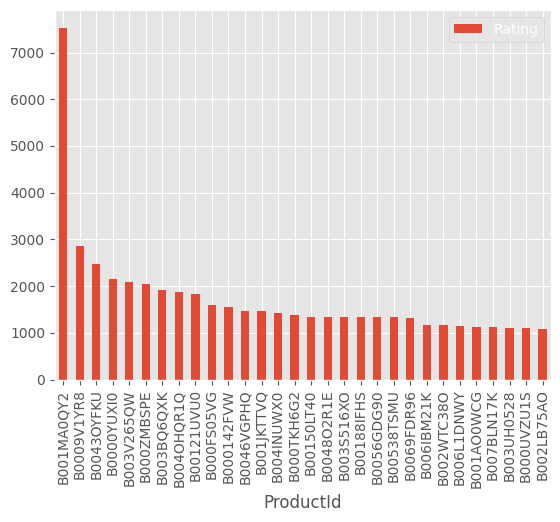

In [126]:
most_popular.head(30).plot(kind = "bar")

## Recommendation System - Part II

### Model-based collaborative filtering system

Recommend items to users based on purchase history and similarity of ratings provided by other users who bought items to that of a particular customer.

A model based collaborative filtering technique is closen here as it helps in making predictinfg products for a particular user by identifying patterns based on preferences from multiple user data.

#### Utility Matrix based on products sold and user reviews

Utility Matrix

An utlity matrix is consists of all possible user-item preferences (ratings) details represented as a matrix. The utility matrix is sparce as none of the users would buy all teh items in the list, hence, most of the values are unknown.

In [127]:
# Subset of Amazon Ratings (ENHANCED: Dense-core sampling for better matrix quality)

def extract_dense_core(df, min_user=10, min_item=20, max_iterations=10):
    """Iteratively prune users/items with too few ratings to get a dense subgraph."""
    for i in range(max_iterations):
        n_before = len(df)
        # Remove items with too few ratings
        item_counts = df['ProductId'].value_counts()
        valid_items = item_counts[item_counts >= min_item].index
        df = df[df['ProductId'].isin(valid_items)]
        # Remove users with too few ratings
        user_counts = df['UserId'].value_counts()
        valid_users = user_counts[user_counts >= min_user].index
        df = df[df['UserId'].isin(valid_users)]
        if len(df) == n_before:
            print(f"  Dense-core converged after {i+1} iterations")
            break  # Converged
    return df

sample_size = CONFIG.get('sample_size', 200_000)
min_user_ratings = CONFIG.get('min_user_ratings', 10)
min_item_ratings = CONFIG.get('min_item_ratings', 20)

# IMPORTANT: Extract dense core from the FULL dataset first, then sample.
# (Sampling first loses the user/item overlap needed for dense-core pruning.)
print(f"Step 1: Extracting dense core from {len(amazon_ratings):,} ratings (min_user={min_user_ratings}, min_item={min_item_ratings})...")
amazon_ratings_dense = extract_dense_core(
    amazon_ratings.copy(),
    min_user=min_user_ratings,
    min_item=min_item_ratings
)
print(f"  Dense core: {len(amazon_ratings_dense):,} ratings, "
      f"{amazon_ratings_dense['UserId'].nunique():,} users, "
      f"{amazon_ratings_dense['ProductId'].nunique():,} products")

# Step 2: Sample from the dense core to limit memory usage
if len(amazon_ratings_dense) > sample_size:
    print(f"Step 2: Sampling {sample_size:,} from dense core...")
    amazon_ratings1 = amazon_ratings_dense.sample(
        n=sample_size,
        random_state=CONFIG['random_state']
    )
    # Re-prune after sampling (some users/items may drop below threshold)
    print("  Re-pruning after sampling...")
    amazon_ratings1 = extract_dense_core(
        amazon_ratings1,
        min_user=max(3, min_user_ratings // 2),  # Relaxed thresholds for subsample
        min_item=max(5, min_item_ratings // 2)
    )
else:
    print(f"Step 2: Using full dense core ({len(amazon_ratings_dense):,} ratings, no sampling needed)")
    amazon_ratings1 = amazon_ratings_dense

# Diagnostics
n_users = amazon_ratings1['UserId'].nunique()
n_items = amazon_ratings1['ProductId'].nunique()
n_ratings = len(amazon_ratings1)
sparsity = 1 - n_ratings / (n_users * n_items) if (n_users * n_items) > 0 else 1.0

print(f"Final dataset:")
print(f"  Users: {n_users:,}")
print(f"  Items: {n_items:,}")
print(f"  Ratings: {n_ratings:,}")
print(f"  Sparsity: {sparsity:.4f} ({sparsity*100:.2f}%)")
if sparsity > 0.995:
    print("  WARNING: Matrix is very sparse (>99.5%). Results may be noisy.")
elif sparsity > 0.99:
    print("  NOTE: Matrix is sparse but acceptable for SVD.")
else:
    print("  GOOD: Matrix density is sufficient for meaningful recommendations.")

# Estimate memory for utility matrix
mem_gb = (n_users * n_items * 8) / (1024**3)
print(f"  Estimated utility matrix memory: {mem_gb:.2f} GB")

if mem_gb > 4:
    print("  WARNING: Matrix may be too large. Consider reducing sample_size.")

Step 1: Extracting dense core from 2,023,070 ratings (min_user=10, min_item=20)...
  Dense-core converged after 7 iterations
  Dense core: 24,280 ratings, 1,185 users, 505 products
Step 2: Using full dense core (24,280 ratings, no sampling needed)
Final dataset:
  Users: 1,185
  Items: 505
  Ratings: 24,280
  Sparsity: 0.9594 (95.94%)
  GOOD: Matrix density is sufficient for meaningful recommendations.
  Estimated utility matrix memory: 0.00 GB


In [128]:
ratings_utility_matrix = amazon_ratings1.pivot_table(values='Rating', index='UserId', columns='ProductId', fill_value=0)
ratings_utility_matrix.head()

ProductId,B0009EILKS,B000AO2NXS,B000E0K7NQ,B000F6RFX4,B000FBNV1Y,B000GUZ8HY,B000H8UN3Y,B000K7E2G6,B000O3OZD6,B000P1S0N8,...,B00KAL5JAU,B00KCFAZTE,B00KCTER3U,B00KD73PBQ,B00KHGIK54,B00KHH2VOY,B00KQ4PEBU,B00KQBR9FM,B00KQVTX06,B00KTLBEEQ
UserId,,,,,,,,,,,,,,,,,,,,,
A100WO06OQR8BQ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A100ZQDV7L8PVV,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A105S56ODHGJEK,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A10E3F50DIUJEE,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A10M94ASQEBL56,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


As expected, the utility matrix obtaned above is sparce, I have filled up the unknown values wth 0.

In [129]:
ratings_utility_matrix.shape

(1185, 505)

Transposing the matrix

In [130]:
X = ratings_utility_matrix.T
X.head()

UserId,A100WO06OQR8BQ,A100ZQDV7L8PVV,A105S56ODHGJEK,A10E3F50DIUJEE,A10M94ASQEBL56,A10PUMFCPP2SXV,A10YFB0VUK1JOP,A10Z8FC0SMU5VQ,A10ZBR6O8S8OCY,A110RS7QL8Q1UX,...,AYCC7GURIXGB8,AYGEP8I4BQ3CK,AYNAH993VDECT,AYOMAHLWRQHUG,AYPIF2S8P3RZT,AYUF7YETYOLNX,AZ26CDSJ363AH,AZA595ZPIG240,AZFHSPEZUPGD2,AZMY6E8B52L2T
ProductId,,,,,,,,,,,,,,,,,,,,,
B0009EILKS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
B000AO2NXS,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0
B000E0K7NQ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,5.0,0.0,4.0,0.0,0.0
B000F6RFX4,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
B000FBNV1Y,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,3.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0


In [131]:
X.shape

(505, 1185)

Unique products in subset of data

In [132]:
X1 = X

### Decomposing the Matrix

Matrix shape: (505, 1185) (items x users)
Max allowed components: 50 (capped at 50)
Finding optimal SVD components...
Optimal components (auto-detected): 50
Using n_components = 50


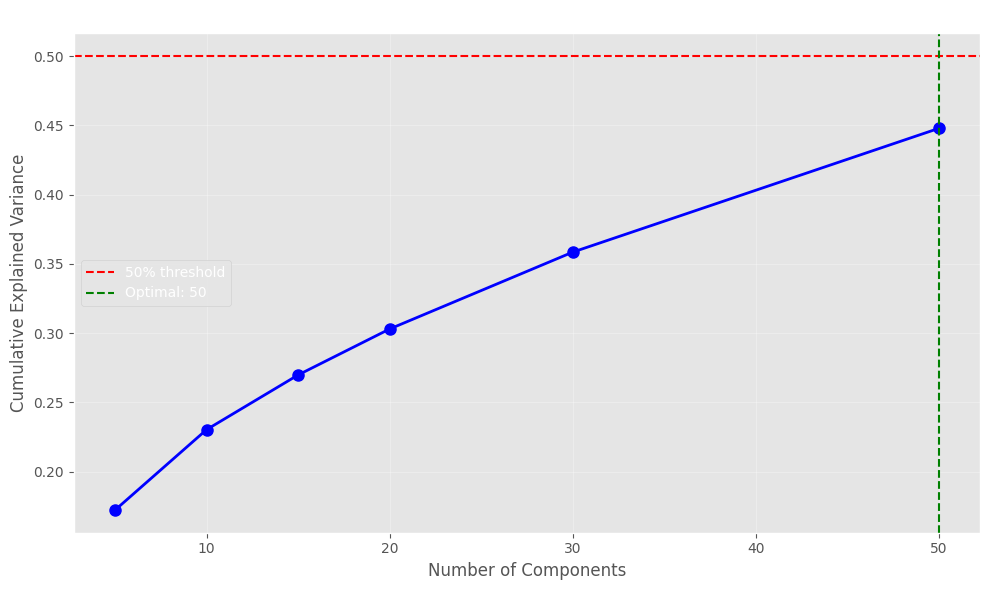

Decomposed matrix shape: (505, 50)
Explained variance: 44.78%


In [133]:
# ENHANCED: SVD with automatic component selection using elbow method

# Cap maximum components to avoid overfitting on sparse data
n_users_svd = X.shape[1]  # number of users (columns after transpose)
n_items_svd = X.shape[0]  # number of items (rows after transpose)
max_components = min(50, n_users_svd - 1, n_items_svd - 1)
max_components = max(1, max_components)  # Safety: never go below 1
print(f"Matrix shape: {X.shape} (items x users)")
print(f"Max allowed components: {max_components} (capped at 50)")

# Find optimal number of components
print("Finding optimal SVD components...")
optimal_n, test_components, explained_variances = find_optimal_svd_components(
    X,
    variance_threshold=CONFIG['svd_variance_threshold'],
    max_components=max_components
)

# Use CONFIG value if set, otherwise use auto-detected (but respect cap)
n_components = CONFIG.get('svd_n_components') or optimal_n
n_components = min(n_components, max_components)
n_components = max(1, n_components)  # Safety: never go below 1
print(f"Optimal components (auto-detected): {optimal_n}")
print(f"Using n_components = {n_components}")

# Plot elbow curve
plot_svd_elbow(test_components, explained_variances, n_components, CONFIG['svd_variance_threshold'])

# Apply SVD with optimal components
SVD = TruncatedSVD(n_components=n_components, random_state=CONFIG['random_state'])
decomposed_matrix = SVD.fit_transform(X)

print(f"Decomposed matrix shape: {decomposed_matrix.shape}")
print(f"Explained variance: {SVD.explained_variance_ratio_.sum():.2%}")

### Correlation Matrix

In [134]:
# ENHANCED: Use cosine similarity (more stable than np.corrcoef)

# Old method (can produce invalid values outside [-1,1]):
# correlation_matrix = np.corrcoef(decomposed_matrix)

# New method: Cosine similarity (bounded [0,1], more stable)
similarity_matrix = compute_cosine_similarity(decomposed_matrix)

print(f"Similarity matrix shape: {similarity_matrix.shape}")
print(f"Min similarity: {similarity_matrix.min():.4f}")
print(f"Max similarity: {similarity_matrix.max():.4f}")
print(f"Mean similarity: {similarity_matrix.mean():.4f}")

# For backwards compatibility with later cells
correlation_matrix = similarity_matrix



Similarity matrix shape: (505, 505)
Min similarity: -0.2251
Max similarity: 1.0000
Mean similarity: 0.1604


correlation_matrix

In [135]:
X.index[99]

'B0039UTO3M'

Index # of product ID purchased by customer

In [136]:
# Select a product from the filtered dataset for demonstration
# (The original product "6117036094" may not exist after filtering)

product_names = list(X.index)

# Pick a product that exists in our filtered data
# Use one from the middle of the list for variety
i = product_names[len(product_names) // 2]  # Pick middle product

print(f"Selected product for recommendation: {i}")
print(f"Total products available: {len(product_names)}")

product_ID = product_names.index(i)
print(f"Product index: {product_ID}")



Selected product for recommendation: B009G0E19Q
Total products available: 505
Product index: 252


Correlation for all items with the item purchased by this customer based on items rated by other customers people who bought the same product

In [137]:
correlation_product_ID = correlation_matrix[product_ID]
correlation_product_ID.shape

(505,)

### Recommending top 10 highly correlated products in sequence

In [138]:
# ENHANCED: Adaptive top-N recommendations (instead of hardcoded 0.90 threshold)

# Old method (problematic - may return 0 or too many results):
# Recommend = list(X.index[correlation_product_ID > 0.90])

# New method: Get top-N most similar products using helper function
top_n = 10
product_names = list(X.index)

recommendations = get_recommendations(
    item_id=i,
    similarity_matrix=similarity_matrix,
    item_names=product_names,
    top_n=top_n
)

# Display recommendations
print(f"Top {top_n} recommendations for product '{i}':")
print("-" * 60)
for rank, rec in enumerate(recommendations, 1):
    print(f"{rank:2d}. {rec['item_id']} (similarity: {rec['similarity']:.4f})")

# For backwards compatibility
Recommend = [rec['item_id'] for rec in recommendations]

Top 10 recommendations for product 'B009G0E19Q':
------------------------------------------------------------
 1. B0098JU8T2 (similarity: 0.5959)
 2. B00FRDPNA2 (similarity: 0.5677)
 3. B00GMWMMOW (similarity: 0.5582)
 4. B00HNKRWX8 (similarity: 0.5402)
 5. B00AXRBAEA (similarity: 0.5342)
 6. B00CA05FO4 (similarity: 0.5337)
 7. B00C67E3GW (similarity: 0.5273)
 8. B00HE88JMC (similarity: 0.5206)
 9. B00HSNWZFU (similarity: 0.5167)
10. B005HIHD2I (similarity: 0.5160)


Product Id #

Here are the top 10 products to be displayed by the recommendation system to the above customer based on the purchase history of other customers in the website.

## Recommendation System - Part III

For a business without any user-item purchase history, a search engine based recommendation system can be designed for users. The product recommendations can be based on textual clustering analysis given in product description.

In [139]:
# Importing libraries

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

## Home Depot's dataset with product dataset:

https://www.kaggle.com/c/home-depot-product-search-relevance/data

### Item to item based recommendation system based on product description

Applicable when business is setting up its E-commerce website for the first time

In [140]:
import os
import zipfile

# Check if data already exists in content folder
data_file = 'content/product_descriptions.csv'

if os.path.exists(data_file):
    print(f"✓ Found {data_file} locally - skipping download")
else:
    print(f"Downloading Home Depot dataset...")
    # Download dataset (requires Kaggle API and competition acceptance)
    !kaggle competitions download -c home-depot-product-search-relevance
    
    # Cross-platform unzip
    zip_file = 'home-depot-product-search-relevance.zip'
    if os.path.exists(zip_file):
        # Create content folder if not exists
        os.makedirs('content', exist_ok=True)
        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            zip_ref.extractall('content/')
        print(f"✓ Extracted {zip_file} successfully")
        # Clean up zip file
        os.remove(zip_file)
    else:
        print(f"Error: {zip_file} not found after download. Ensure you accepted the competition rules on Kaggle.")

✓ Found content/product_descriptions.csv locally - skipping download


In [141]:
product_descriptions = pd.read_csv('content/product_descriptions.csv')
product_descriptions.shape

(124428, 2)

#### Checking for missing values

In [142]:
# Missing values

product_descriptions = product_descriptions.dropna()
product_descriptions.shape
product_descriptions.head()

,product_uid,product_description
0,100001,"Not only do angles make joints stronger, they ..."
1,100002,BEHR Premium Textured DECKOVER is an innovativ...
2,100003,Classic architecture meets contemporary design...
3,100004,The Grape Solar 265-Watt Polycrystalline PV So...
4,100005,Update your bathroom with the Delta Vero Singl...


In [143]:
# Use ALL product descriptions (not just 500)
product_descriptions1 = product_descriptions.dropna(subset=['product_description'])
product_descriptions1 = product_descriptions1[product_descriptions1['product_description'].str.strip().str.len() > 10]
print(f"Using {len(product_descriptions1):,} product descriptions (was limited to 500)")

product_descriptions1["product_description"].head(10)

Using 124,427 product descriptions (was limited to 500)


0    Not only do angles make joints stronger, they ...
1    BEHR Premium Textured DECKOVER is an innovativ...
2    Classic architecture meets contemporary design...
3    The Grape Solar 265-Watt Polycrystalline PV So...
4    Update your bathroom with the Delta Vero Singl...
5    Achieving delicious results is almost effortle...
6    The Quantum Adjustable 2-Light LED Black Emerg...
7    The Teks #10 x 1-1/2 in. Zinc-Plated Steel Was...
8    Get the House of Fara 3/4 in. x 3 in. x 8 ft. ...
9    Valley View Industries Metal Stakes (4-Pack) a...
Name: product_description, dtype: object

#### Feature extraction from product descriptions

Converting the text in product description into numerical data for analysis

In [144]:
# ENHANCED: TF-IDF with tuned parameters from CONFIG

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=CONFIG['tfidf_max_features'],
    min_df=CONFIG['tfidf_min_df'],
    max_df=CONFIG['tfidf_max_df'],
    ngram_range=CONFIG['tfidf_ngram_range'],
    sublinear_tf=True,
    norm='l2'
)

X_tfidf = vectorizer.fit_transform(product_descriptions1["product_description"])

print(f"TF-IDF matrix shape: {X_tfidf.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_):,}")
print(f"Sample feature names: {vectorizer.get_feature_names_out()[:10].tolist()}")

TF-IDF matrix shape: (124427, 5000)
Vocabulary size: 5,000
Sample feature names: ['000', '000 btu', '000 hours', '000 sq', '0ah', '10', '10 000', '10 ft', '10 mm', '10 overage']


#### Visualizing product clusters in subset of data

Finding optimal number of clusters...
Optimal K (Silhouette): 19
Optimal K (Elbow): 8
Using n_clusters = 19


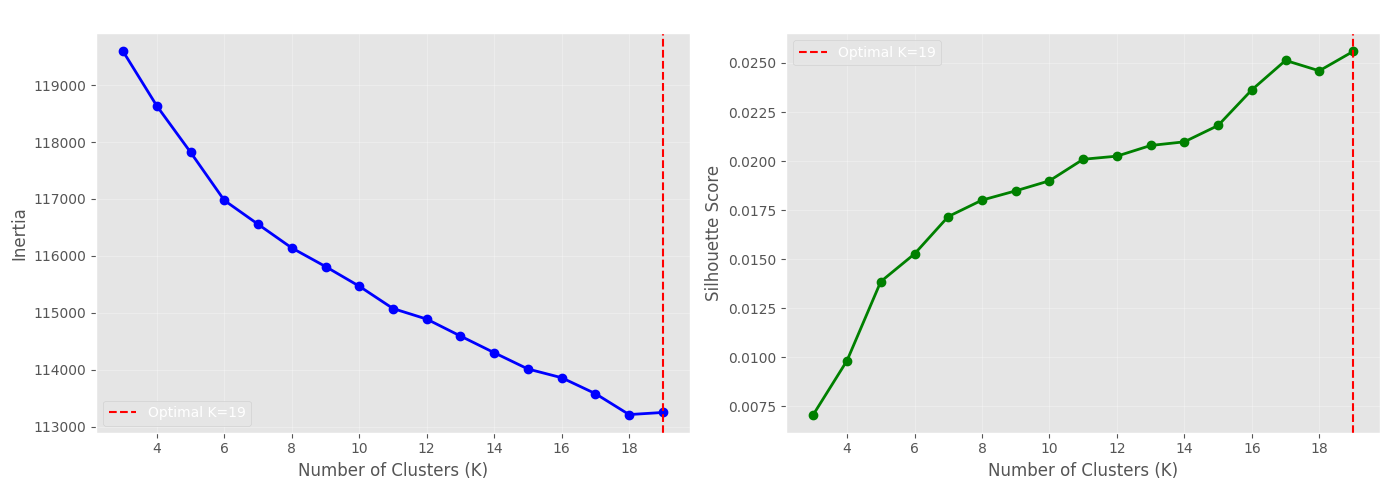


Cluster distribution:
  Cluster 0: 3909 products (3.1%)
  Cluster 1: 5597 products (4.5%)
  Cluster 2: 2104 products (1.7%)
  Cluster 3: 44745 products (36.0%)
  Cluster 4: 10754 products (8.6%)
  Cluster 5: 6571 products (5.3%)
  Cluster 6: 5033 products (4.0%)
  Cluster 7: 859 products (0.7%)
  Cluster 8: 7952 products (6.4%)
  Cluster 9: 5679 products (4.6%)
  Cluster 10: 2310 products (1.9%)
  Cluster 11: 5493 products (4.4%)
  Cluster 12: 1591 products (1.3%)
  Cluster 13: 1303 products (1.0%)
  Cluster 14: 3697 products (3.0%)
  Cluster 15: 11297 products (9.1%)
  Cluster 16: 447 products (0.4%)
  Cluster 17: 3624 products (2.9%)
  Cluster 18: 1462 products (1.2%)


In [145]:
# ENHANCED: KMeans with automatic K selection using silhouette score

X_cluster = X_tfidf

# Find optimal number of clusters
print("Finding optimal number of clusters...")
optimal_k_sil, optimal_k_elbow, k_range, inertias, silhouettes = find_optimal_clusters(
    X_cluster,
    k_range=CONFIG['kmeans_k_range'],
    n_init=CONFIG['kmeans_n_init']
)

# Use CONFIG value if set, otherwise use silhouette-based selection
n_clusters = CONFIG.get('kmeans_n_clusters') or optimal_k_sil
print(f"Optimal K (Silhouette): {optimal_k_sil}")
print(f"Optimal K (Elbow): {optimal_k_elbow}")
print(f"Using n_clusters = {n_clusters}")

# Plot cluster analysis
plot_cluster_analysis(k_range, inertias, silhouettes, n_clusters)

# Fit KMeans with optimal K
kmeans = KMeans(
    n_clusters=n_clusters,
    init='k-means++',
    n_init=CONFIG['kmeans_n_init'],
    random_state=CONFIG['random_state']
)
y_kmeans = kmeans.fit_predict(X_cluster)

print(f"\nCluster distribution:")
unique, counts = np.unique(y_kmeans, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} products ({count/len(y_kmeans)*100:.1f}%)")

#### Top words in each cluster based on product description

In [146]:
# Top terms per cluster (using the optimized kmeans model from above)

print("Top terms per cluster:")
print("=" * 50)

order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

for i in range(kmeans.n_clusters):
    print(f"Cluster {i}:")
    top_terms = [terms[ind] for ind in order_centroids[i, :10] if ind < len(terms)]
    print("  " + ", ".join(top_terms))

Top terms per cluster:
Cluster 0:
  cable, listed, ul, wire, conduit, electrical, circuit, amp, use, ul listed
Cluster 1:
  fabric, outdoor, coated, post, powder, powder coated, patio, fence, weather, resistant
Cluster 2:
  cu ft, cu, oven, cooking, food, delivery, freezer, controls, options, ft
Cluster 3:
  easy, use, steel, used, designed, ft, design, durable, home, high
Cluster 4:
  plan, depot protection, protection plan, protection, depot, led, light, power, lights, battery
Cluster 5:
  door, doors, glass, shower, hardware, security, tempered, steel, panel, sliding
Cluster 6:
  light, watt, fixture, glass, bulb, lighting, bulbs, collection, finish, lamp
Cluster 7:
  fan, ceiling fan, ceiling, blades, fan installation, help ceiling, electricians help, depot licensed, licensed electricians, help
Cluster 8:
  cabinet, vanity, sink, storage, hardware, drawer, bathroom, shelf, finish, design
Cluster 9:
  cutting, blade, tool, saw, bit, blades, speed, cut, drill, bits
Cluster 10:
  tile

#### Predicting clusters based on key search words

cutting tool

In [147]:
print("Cluster ID:")
Y = vectorizer.transform(["cutting tool"])
prediction = kmeans.predict(Y)
print(prediction)

Cluster ID:
[9]


spray paint

In [148]:
print("Cluster ID:")
Y = vectorizer.transform(["spray paint"])
prediction = kmeans.predict(Y)
print(prediction)

Cluster ID:
[3]


steel drill

In [149]:
print("Cluster ID:")
Y = vectorizer.transform(["steel drill"])
prediction = kmeans.predict(Y)
print(prediction)

Cluster ID:
[9]


In case a word appears in multiple clusters, the algorithm chooses the cluster with the highest frequency of occurance of the word.

water

In [150]:
print("Cluster ID:")
Y = vectorizer.transform(["water"])
prediction = kmeans.predict(Y)
print(prediction)

Cluster ID:
[11]


In [151]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import numpy as np

# A comprehensive list of Arabic stop words (extended)
arabic_stop_words = [
    "ء", "آ", "أ", "ؤ", "إ", "ئ", "ا", "ب", "ت", "ث",
    "ج", "ح", "خ", "د", "ذ", "ر", "ز", "س", "ش", "ص",
    "ض", "ط", "ظ", "ع", "غ", "ف", "ق", "ك", "ل", "م",
    "ن", "ه", "و", "ي", "ة", "ى",
    "في", "على", "من", "إلى",
    "هذا", "هذه", "الذي", "التي",
    "عن", "أن", "ما", "هو", "هي",
    "كان", "كانت", "لم", "لا",
    # Extended stop words
    "ذلك", "تلك", "هناك", "يكون", "تكون",
    "سوف", "قد", "لقد", "إذا", "عندما",
    "حتى", "بعد", "قبل", "بين", "كل", "بعض", "أي",
    "الذين", "اللذين", "اللتين",
    "لن", "لكن", "أو", "ثم", "حيث", "كيف",
    "أنا", "نحن", "أنت", "أنتم", "هم", "هن",
    "كانوا", "ليس", "ليست", "وهو", "وهي",
    "فيها", "فيه", "منها", "منه", "عليه", "عليها",
    "التى", "الذى", "يتم", "تم", "وقد", "ولا",
    "هل", "مع", "عند", "غير", "أيضا", "خلال",
    "بعض", "كما", "لها", "له", "جدا", "ذات",
]

# Extended list for content-based (used later when fitting on full corpus)
arabic_stop_words_extended = arabic_stop_words.copy()

print(f"Arabic stop words: {len(arabic_stop_words)} base + extended = {len(arabic_stop_words_extended)} total")
print("Note: Arabic TF-IDF vectorizer will be fit on the FULL review corpus (not sample texts)")

Arabic stop words: 114 base + extended = 114 total
Note: Arabic TF-IDF vectorizer will be fit on the FULL review corpus (not sample texts)


### Popularity-Based Recommendation System for Arabic Data

#### Loading the Arabic dataset

In [152]:
import os
import zipfile

# Check if data already exists in content folder
data_file = 'content/CompanyReviews.csv'

if os.path.exists(data_file):
    print(f"✓ Found {data_file} locally - skipping download")
else:
    print(f"Downloading Arabic company reviews dataset...")
    # Download Arabic company reviews dataset
    !kaggle datasets download -d fahdseddik/arabic-company-reviews
    
    # Cross-platform unzip
    zip_file = 'arabic-company-reviews.zip'
    if os.path.exists(zip_file):
        # Create content folder if not exists
        os.makedirs('content', exist_ok=True)
        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            zip_ref.extractall('content/')
        print(f"✓ Extracted {zip_file} to content/ folder")
        # Clean up zip file
        os.remove(zip_file)
    else:
        print(f"Error: {zip_file} not found after download")

✓ Found content/CompanyReviews.csv locally - skipping download


In [153]:
import pandas as pd

# Replace 'your_arabic_ratings_data.csv' with the actual path to your Arabic data file
try:
    arabic_ratings = pd.read_csv('content/CompanyReviews.csv')
    # Handle missing values if necessary
    arabic_ratings = arabic_ratings.dropna()
    print("Arabic dataset loaded successfully.")
    print(arabic_ratings.head())
except FileNotFoundError:
    print("Error: 'your_arabic_ratings_data.csv' not found. Please replace with the correct file path.")
    # Create a dummy DataFrame for demonstration if the file is not found
    arabic_ratings = pd.DataFrame({
        'UserId': ['user1', 'user2', 'user3', 'user1', 'user2'],
        'ProductId': ['منتج_أ', 'منتج_ب', 'منتج_أ', 'منتج_ج', 'منتج_ب'],
        'Rating': [5, 4, 5, 3, 4],
        'Timestamp': [1, 2, 3, 4, 5]
    })
    print("\nUsing dummy data for demonstration:")
    print(arabic_ratings.head())

Arabic dataset loaded successfully.
   Unnamed: 0                                 review_description  rating  \
0           0                                               رائع       1   
1           1  برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...       1   
2           2  التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...      -1   
3           3                 لماذا لا يمكننا طلب من ماكدونالدز؟      -1   
4           4  البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...      -1   

  company  
0  talbat  
1  talbat  
2  talbat  
3  talbat  
4  talbat  


In [154]:
# ENHANCED: Arabic Text Preprocessing
# Apply advanced preprocessing to Arabic reviews

print("Applying Arabic text preprocessing...")

# Preprocess review descriptions
arabic_ratings['review_clean'] = arabic_ratings['review_description'].apply(preprocess_arabic)

# Show preprocessing examples
print("\nPreprocessing examples:")
print("-" * 60)
for idx in range(min(3, len(arabic_ratings))):
    original = arabic_ratings.iloc[idx]['review_description']
    cleaned = arabic_ratings.iloc[idx]['review_clean']
    print(f"Original: {str(original)[:50]}...")
    print(f"Cleaned:  {str(cleaned)[:50]}...")
    print()

# Handle data imbalance (optional - based on CONFIG)
if CONFIG.get('arabic_max_samples_per_company'):
    max_samples = CONFIG['arabic_max_samples_per_company']
    print(f"\nBalancing data: max {max_samples} samples per company...")

    original_size = len(arabic_ratings)
    arabic_ratings_balanced = arabic_ratings.groupby('company').apply(
        lambda x: x.sample(n=min(len(x), max_samples), random_state=CONFIG['random_state'])
    ).reset_index(drop=True)

    print(f"Original size: {original_size:,}")
    print(f"Balanced size: {len(arabic_ratings_balanced):,}")
else:
    arabic_ratings_balanced = arabic_ratings

print("\nArabic preprocessing complete!")

Applying Arabic text preprocessing...

Preprocessing examples:
------------------------------------------------------------
Original: رائع...
Cleaned:  رائع...

Original: برنامج رائع جدا يساعد على تلبيه الاحتياجات بشكل اس...
Cleaned:  برنامج رائع جدا يساعد على تلبيه الاحتياجات بشكل اس...

Original: التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال بالشبك...
Cleaned:  التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال بالشبك...


Balancing data: max 1000 samples per company...
Original size: 40,045
Balanced size: 4,190

Arabic preprocessing complete!


C:\Users\mohamed.qiaty\AppData\Local\Temp\ipykernel_37204\1892824887.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  arabic_ratings_balanced = arabic_ratings.groupby('company').apply(


#### Calculating Popularity

In [155]:
if not arabic_ratings.empty:
    arabic_popular_products = pd.DataFrame(arabic_ratings.groupby('company')['rating'].count())
    arabic_most_popular = arabic_popular_products.sort_values('rating', ascending=False)

    print("\nTop 10 most popular Arabic companies based on rating count:")
    display(arabic_most_popular.head(10))
else:
    print("\nCannot calculate popularity as the Arabic dataset is empty.")


Top 10 most popular Arabic companies based on rating count:


,rating
company,
talbat,32072
swvl,4693
telecom_egypt,2090
venus,281
Raya,268
TMG,250
elsewedy,147
hilton,100
capiter,73


In [156]:
print(arabic_ratings.columns)

Index(['Unnamed: 0', 'review_description', 'rating', 'company',
       'review_clean'],
      dtype='object')


### Model-based collaborative filtering system for Arabic Data

#### Utility Matrix based on companies and user ratings

In [157]:
# Create the utility matrix for Arabic data

# Fix column name: 'Unnamed: 0' is just a row index, rename it clearly
if 'Unnamed: 0' in arabic_ratings.columns:
    arabic_ratings = arabic_ratings.rename(columns={'Unnamed: 0': 'reviewer_id'})

reviewer_col = 'reviewer_id' if 'reviewer_id' in arabic_ratings.columns else arabic_ratings.columns[0]

arabic_ratings_utility_matrix = arabic_ratings.pivot_table(
    values='rating', index=reviewer_col, columns='company', fill_value=0
)

n_arabic_items = arabic_ratings_utility_matrix.shape[1]
print(f"\nArabic Ratings Utility Matrix:")
print(f"  Shape: {arabic_ratings_utility_matrix.shape}")
print(f"  Items (companies): {n_arabic_items}")

if n_arabic_items < 20:
    print(f"\nWARNING: Arabic CF has only {n_arabic_items} items (companies).")
    print("With so few items, collaborative filtering has limited value.")
    print("This section demonstrates the technique on small data.\n")

display(arabic_ratings_utility_matrix.head())


Arabic Ratings Utility Matrix:
  Shape: (39540, 12)
  Items (companies): 12

With so few items, collaborative filtering has limited value.
This section demonstrates the technique on small data.



company,Ezz Steel,Raya,TMG,capiter,domty,elsewedy,hilton,nestle,swvl,talbat,telecom_egypt,venus
reviewer_id,,,,,,,,,,,,
0,0.0,0.0,-1.0,1.0,0.0,0.0,0.0,0.0,-1.0,1.0,0.0,0.0
1,-1.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,-1.0,1.0,0.0,0.0
2,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0
3,-1.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0
4,-1.0,0.0,-1.0,1.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0


Transposing the matrix

In [158]:
X_arabic_cf = arabic_ratings_utility_matrix.T
print("\nTransposed Arabic Utility Matrix:")
display(X_arabic_cf.head())
print("\nShape of Transposed Arabic Utility Matrix:", X_arabic_cf.shape)


Transposed Arabic Utility Matrix:


reviewer_id,0,1,2,3,4,5,6,7,8,9,...,39531,39532,39533,39534,39535,39536,39537,39538,39539,39540
company,,,,,,,,,,,,,,,,,,,,,
Ezz Steel,0.0,-1.0,1.0,-1.0,-1.0,1.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Raya,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TMG,-1.0,1.0,1.0,-1.0,-1.0,1.0,-1.0,1.0,1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
capiter,1.0,-1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
domty,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Shape of Transposed Arabic Utility Matrix: (12, 39540)


### Decomposing the Matrix (Arabic Data)

In [159]:
from sklearn.decomposition import TruncatedSVD

# Reduce components to be proportional to items (at most n_items - 1, and at most 5)
n_arabic_items = X_arabic_cf.shape[0]  # number of companies
n_components_arabic = min(5, n_arabic_items - 1)
print(f"Arabic SVD: {n_arabic_items} items -> using {n_components_arabic} components")

SVD_arabic = TruncatedSVD(n_components=n_components_arabic, random_state=CONFIG['random_state'])
decomposed_matrix_arabic = SVD_arabic.fit_transform(X_arabic_cf)

print(f"Decomposed matrix shape: {decomposed_matrix_arabic.shape}")
print(f"Explained variance: {SVD_arabic.explained_variance_ratio_.sum():.2%}")

Arabic SVD: 12 items -> using 5 components
Decomposed matrix shape: (12, 5)
Explained variance: 98.43%


### Correlation Matrix (Arabic Data)

In [160]:
import numpy as np

# Calculate the correlation matrix
correlation_matrix_arabic = np.corrcoef(decomposed_matrix_arabic)
print("\nShape of Arabic Correlation Matrix:", correlation_matrix_arabic.shape) # Typo fixed here


Shape of Arabic Correlation Matrix: (12, 12)


### Recommending companies based on correlation (Arabic Data)

Assuming a customer interacts with a specific company (e.g., 'talbat')

In [161]:
# Improved recommendation with adaptive threshold

company_of_interest = 'talbat'

# Get the index of the company of interest
company_names_arabic = list(X_arabic_cf.index)
try:
    company_ID_arabic = company_names_arabic.index(company_of_interest)
    print(f"\nIndex of '{company_of_interest}': {company_ID_arabic}")

    # Get the correlation for all companies with the company of interest
    correlation_company_ID_arabic = correlation_matrix_arabic[company_ID_arabic]

    # Show all correlations for debugging
    print(f"\nCorrelations with '{company_of_interest}':")
    for i, (company, corr) in enumerate(zip(company_names_arabic, correlation_company_ID_arabic)):
        print(f"  {company}: {corr:.4f}")

    # Use adaptive threshold: top N companies by correlation (excluding self)
    # Sort by correlation descending
    sorted_indices = np.argsort(correlation_company_ID_arabic)[::-1]

    # Get top N recommendations (excluding the company itself)
    top_n = 5
    Recommend_arabic = []
    for idx in sorted_indices:
        if company_names_arabic[idx] != company_of_interest:
            Recommend_arabic.append({
                'company': company_names_arabic[idx],
                'correlation': correlation_company_ID_arabic[idx]
            })
        if len(Recommend_arabic) >= top_n:
            break

    print(f"\nTop {top_n} recommended companies based on interaction with '{company_of_interest}':")
    for rec in Recommend_arabic:
        print(f"  {rec['company']}: correlation = {rec['correlation']:.4f}")

except ValueError:
    print(f"\nCompany '{company_of_interest}' not found in the dataset.")


Index of 'talbat': 9

Correlations with 'talbat':
  Ezz Steel: -0.0674
  Raya: -0.2500
  TMG: -0.8305
  capiter: 0.1880
  domty: 0.3095
  elsewedy: -0.3969
  hilton: -0.0135
  nestle: -0.3989
  swvl: 0.2507
  talbat: 1.0000
  telecom_egypt: -0.2500
  venus: 0.2500

Top 5 recommended companies based on interaction with 'talbat':
  domty: correlation = 0.3095
  swvl: correlation = 0.2507
  venus: correlation = 0.2500
  capiter: correlation = 0.1880
  hilton: correlation = -0.0135


### Offline Evaluation for Collaborative Filtering (Arabic Data)

#### Splitting the data into training and testing sets

In [162]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
train_data, test_data = train_test_split(arabic_ratings, test_size=0.2, random_state=42)

print("Shape of training data:", train_data.shape)
print("Shape of testing data:", test_data.shape)

Shape of training data: (32036, 5)
Shape of testing data: (8009, 5)


#### Building the utility matrix and SVD model on the training data

In [163]:
# Create the utility matrix for the training data
reviewer_col = 'reviewer_id' if 'reviewer_id' in train_data.columns else 'Unnamed: 0'
train_data_utility_matrix = train_data.pivot_table(values='rating', index=reviewer_col, columns='company', fill_value=0)

# Transpose the matrix
X_train_cf = train_data_utility_matrix.T

# Apply SVD with reduced components (proportional to items)
n_train_items = X_train_cf.shape[0]
n_components_train = min(5, n_train_items - 1)
SVD_train = TruncatedSVD(n_components=n_components_train, random_state=CONFIG['random_state'])
decomposed_matrix_train = SVD_train.fit_transform(X_train_cf)

# Calculate the correlation matrix
correlation_matrix_train = np.corrcoef(decomposed_matrix_train)

print("Shape of training utility matrix:", train_data_utility_matrix.shape)
print("Shape of transposed training matrix:", X_train_cf.shape)
print(f"SVD components used: {n_components_train}")
print("Shape of decomposed training matrix:", decomposed_matrix_train.shape)
print("Shape of training correlation matrix:", correlation_matrix_train.shape)

Shape of training utility matrix: (31687, 12)
Shape of transposed training matrix: (12, 31687)
SVD components used: 5
Shape of decomposed training matrix: (12, 5)
Shape of training correlation matrix: (12, 12)


#### Evaluating the model on the testing data (Predicting ratings and calculating RMSE)

In [164]:
from sklearn.metrics import mean_squared_error

# Create a utility matrix for the test data
reviewer_col = 'reviewer_id' if 'reviewer_id' in test_data.columns else 'Unnamed: 0'
test_data_utility_matrix = test_data.pivot_table(values='rating', index=reviewer_col, columns='company', fill_value=0).reindex(columns=train_data_utility_matrix.columns, fill_value=0)

# Get the list of companies from the training matrix
train_companies = list(train_data_utility_matrix.columns)

# Function to predict rating for a user-company pair
def predict_rating(user_id, company_name, train_utility_matrix, svd_model, train_companies, correlation_matrix):
    try:
        user_index = list(train_utility_matrix.index).index(user_id)
        try:
            company_index = train_companies.index(company_name)
        except ValueError:
            return None

        company_correlation = correlation_matrix[company_index]
        user_ratings = train_utility_matrix.loc[user_id].values

        numerator = np.sum(company_correlation * user_ratings)
        denominator = np.sum(np.abs(company_correlation))

        if denominator == 0:
            return train_utility_matrix[company_name].mean()

        predicted_rating = numerator / denominator
        return predicted_rating
    except ValueError:
        return None

# Prepare data for RMSE calculation
actual_ratings = []
predicted_ratings = []

for index, row in test_data.iterrows():
    user_id = row[reviewer_col]
    company_name = row['company']
    actual_rating = row['rating']

    predicted_rating = predict_rating(user_id, company_name, train_data_utility_matrix, SVD_train, train_companies, correlation_matrix_train)

    if predicted_rating is not None:
        actual_ratings.append(actual_rating)
        predicted_ratings.append(predicted_rating)

# Calculate RMSE
if actual_ratings and predicted_ratings:
    rmse = np.sqrt(mean_squared_error(actual_ratings, predicted_ratings))
    print(f"\nRMSE on the test set: {rmse}")
else:
    print("\nCould not make any predictions on the test set with the current model and data.")


RMSE on the test set: 0.9688240159662019


In [165]:
# Comprehensive Evaluation Metrics for Recommendation Systems
import numpy as np
from sklearn.metrics import mean_squared_error

def precision_at_k(actual, predicted, k):
    """Calculate Precision@K: proportion of recommended items that are relevant."""
    if len(predicted) > k:
        predicted = predicted[:k]
    if not actual or not predicted:
        return 0.0
    relevant_count = len(set(predicted) & set(actual))
    return relevant_count / len(predicted)

def recall_at_k(actual, predicted, k):
    """Calculate Recall@K: proportion of relevant items that are recommended."""
    if len(predicted) > k:
        predicted = predicted[:k]
    if not actual:
        return 0.0
    relevant_count = len(set(predicted) & set(actual))
    return relevant_count / len(actual)

def dcg_at_k(relevances, k):
    """Calculate Discounted Cumulative Gain at K."""
    relevances = np.asarray(relevances)[:k]
    if relevances.size:
        return np.sum(relevances / np.log2(np.arange(2, relevances.size + 2)))
    return 0.0

def ndcg_at_k(actual, predicted, k):
    """Calculate Normalized Discounted Cumulative Gain at K."""
    if len(predicted) > k:
        predicted = predicted[:k]
    # Binary relevance: 1 if item is relevant, 0 otherwise
    relevances = [1 if item in actual else 0 for item in predicted]
    dcg = dcg_at_k(relevances, k)
    # Ideal DCG: all relevant items at top
    ideal_relevances = sorted(relevances, reverse=True)
    idcg = dcg_at_k(ideal_relevances, k)
    if idcg == 0:
        return 0.0
    return dcg / idcg

def mean_average_precision(actual_list, predicted_list, k):
    """Calculate Mean Average Precision across all users."""
    aps = []
    for actual, predicted in zip(actual_list, predicted_list):
        if not actual:
            continue
        relevant_count = 0
        precision_sum = 0
        for i, item in enumerate(predicted[:k]):
            if item in actual:
                relevant_count += 1
                precision_sum += relevant_count / (i + 1)
        if relevant_count > 0:
            aps.append(precision_sum / min(len(actual), k))
    return np.mean(aps) if aps else 0.0

# Evaluate the recommendation system with multiple metrics
def evaluate_recommendations(train_data, test_data, correlation_matrix, train_companies, k=5):
    """Comprehensive evaluation of recommendation system."""
    reviewer_col = 'reviewer_id' if 'reviewer_id' in test_data.columns else 'Unnamed: 0'
    test_user_items = test_data.groupby(reviewer_col)['company'].apply(list).to_dict()
    train_user_items = train_data.groupby(reviewer_col)['company'].apply(list).to_dict()

    precision_scores = []
    recall_scores = []
    ndcg_scores = []

    for user_id, actual_items in test_user_items.items():
        if user_id not in train_user_items:
            continue
        user_train_items = train_user_items.get(user_id, [])
        if not user_train_items:
            continue

        # Generate recommendations based on items user interacted with
        recommendations = set()
        for item in user_train_items:
            if item in train_companies:
                item_idx = train_companies.index(item)
                item_corrs = correlation_matrix[item_idx]
                top_indices = np.argsort(item_corrs)[::-1][:k+1]
                for idx in top_indices:
                    if train_companies[idx] != item:
                        recommendations.add(train_companies[idx])

        predicted = list(recommendations)[:k]
        if not predicted:
            continue

        # Calculate metrics
        precision_scores.append(precision_at_k(actual_items, predicted, k))
        recall_scores.append(recall_at_k(actual_items, predicted, k))
        ndcg_scores.append(ndcg_at_k(actual_items, predicted, k))

    return {
        'Precision@K': np.mean(precision_scores) if precision_scores else 0.0,
        'Recall@K': np.mean(recall_scores) if recall_scores else 0.0,
        'NDCG@K': np.mean(ndcg_scores) if ndcg_scores else 0.0
    }

# Run comprehensive evaluation
print("=" * 50)
print("Comprehensive Recommendation System Evaluation")
print("=" * 50)

# First, the RMSE we already calculated
print(f"\n1. RMSE (Rating Prediction): {rmse:.4f}")

# Calculate ranking metrics
train_companies_list = list(train_data_utility_matrix.columns)
ranking_metrics = evaluate_recommendations(
    train_data, test_data,
    correlation_matrix_train, train_companies_list,
    k=5
)

print(f"\n2. Ranking Metrics (k=5):")
print(f"   Precision@5: {ranking_metrics['Precision@K']:.4f}")
print(f"   Recall@5: {ranking_metrics['Recall@K']:.4f}")
print(f"   NDCG@5: {ranking_metrics['NDCG@K']:.4f}")

# Coverage: what proportion of items can be recommended
recommended_items = set()
for company in train_companies_list:
    if company in train_companies_list:
        company_idx = train_companies_list.index(company)
        correlations = correlation_matrix_train[company_idx]
        for i, corr in enumerate(correlations):
            if corr > 0.1 and train_companies_list[i] != company:
                recommended_items.add(train_companies_list[i])

coverage = len(recommended_items) / len(train_companies_list) if train_companies_list else 0
print(f"\n3. Coverage: {coverage:.4f} ({len(recommended_items)}/{len(train_companies_list)} items)")

print("\n" + "=" * 50)

Comprehensive Recommendation System Evaluation

1. RMSE (Rating Prediction): 0.9688

2. Ranking Metrics (k=5):
   Precision@5: 0.0480
   Recall@5: 0.1333
   NDCG@5: 0.0940

3. Coverage: 1.0000 (12/12 items)



## Recommendation System - Part III (Arabic Data)

### Item to item based recommendation system based on review descriptions (Arabic Data)

#### Feature extraction from review descriptions (Arabic Data)

In [166]:
# FIXED: Create a FRESH TF-IDF vectorizer fit on ALL Arabic review descriptions
# (Previous version incorrectly used a vectorizer fit on only 5 sample texts)

# Use preprocessed text if available, otherwise raw descriptions
text_column = 'review_clean' if 'review_clean' in arabic_ratings.columns else 'review_description'
arabic_descriptions = arabic_ratings[text_column].dropna()
arabic_descriptions = arabic_descriptions[arabic_descriptions.str.strip().str.len() > 5]

print(f"Arabic reviews for TF-IDF: {len(arabic_descriptions):,}")

# Create a NEW vectorizer with proper parameters for the full corpus
vectorizer_ar = TfidfVectorizer(
    stop_words=arabic_stop_words_extended,
    max_features=CONFIG.get('arabic_tfidf_max_features', 10000),
    min_df=3,
    max_df=0.90,
    ngram_range=(1, 2),
    sublinear_tf=True,
    norm='l2'
)

X_arabic_text = vectorizer_ar.fit_transform(arabic_descriptions)

print(f"Arabic TF-IDF matrix shape: {X_arabic_text.shape}")
print(f"Vocabulary size: {len(vectorizer_ar.vocabulary_):,}")
print(f"Sample features: {vectorizer_ar.get_feature_names_out()[:10].tolist()}")

Arabic reviews for TF-IDF: 35,843
Arabic TF-IDF matrix shape: (35843, 10000)
Vocabulary size: 10,000
Sample features: ['ائتمان', 'ائتمانيه', 'اابرنامج', 'اب', 'اب ستور', 'ابا', 'ابحث', 'ابحث مطعم', 'ابد', 'ابدا']


#### Visualizing review clusters in Arabic data

Testing K range: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
  K=3: silhouette=0.0218
  K=4: silhouette=0.0190
  K=5: silhouette=0.0208
  K=6: silhouette=0.0216
  K=7: silhouette=0.0248
  K=8: silhouette=0.0237
  K=9: silhouette=0.0232
  K=10: silhouette=0.0225
  K=11: silhouette=0.0234
  K=12: silhouette=0.0216
  K=13: silhouette=0.0247
  K=14: silhouette=0.0245

Optimal Arabic clusters: 7 (silhouette: 0.0248)


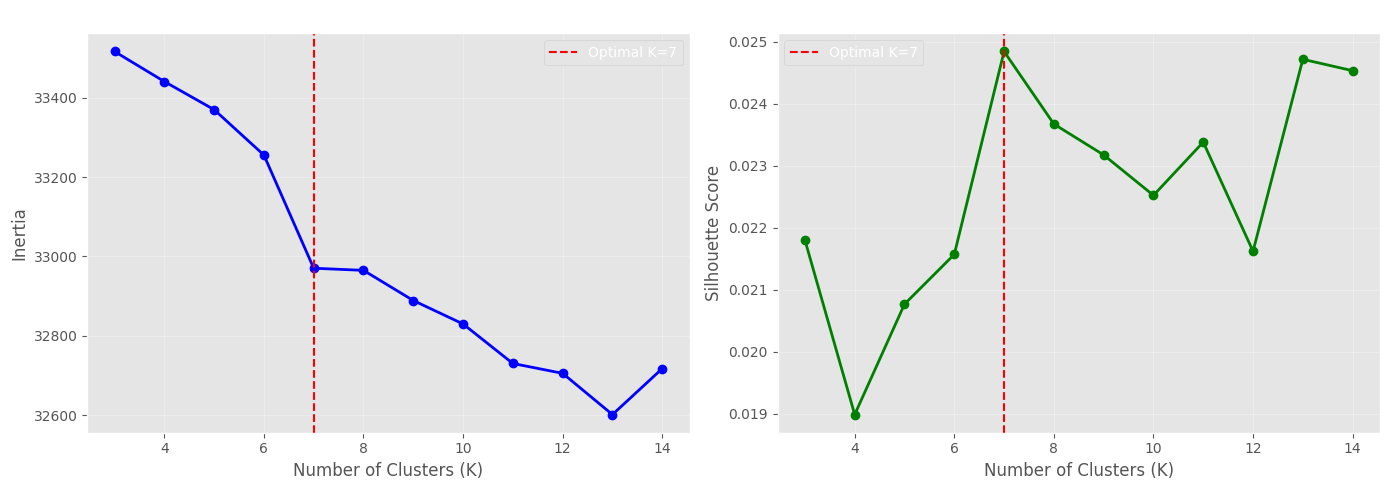


Cluster distribution:
  Cluster 0: 26854 reviews (74.9%)
  Cluster 1: 710 reviews (2.0%)
  Cluster 2: 1907 reviews (5.3%)
  Cluster 3: 2058 reviews (5.7%)
  Cluster 4: 1272 reviews (3.5%)
  Cluster 5: 1183 reviews (3.3%)
  Cluster 6: 1859 reviews (5.2%)


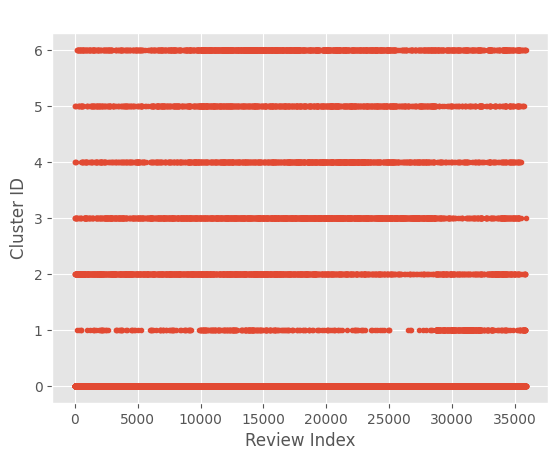

In [167]:
# ENHANCED: Arabic KMeans with automatic K selection using silhouette score
from sklearn.metrics import silhouette_score

X_for_clustering_ar = X_arabic_text

# Test range of cluster counts
arabic_k_range = CONFIG.get('arabic_kmeans_k_range', range(3, 15))
# Ensure we don't exceed data size
max_k = min(max(arabic_k_range), len(arabic_descriptions) // 50)
arabic_k_range = range(min(arabic_k_range), max_k + 1)

print(f"Testing K range: {list(arabic_k_range)}")

arabic_inertias = []
arabic_silhouette_scores = []

for k in arabic_k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=CONFIG['random_state'])
    labels = km.fit_predict(X_for_clustering_ar)
    arabic_inertias.append(km.inertia_)
    score = silhouette_score(X_for_clustering_ar, labels, sample_size=min(5000, X_for_clustering_ar.shape[0]))
    arabic_silhouette_scores.append(score)
    print(f"  K={k}: silhouette={score:.4f}")

best_k_arabic = list(arabic_k_range)[np.argmax(arabic_silhouette_scores)]
print(f"\nOptimal Arabic clusters: {best_k_arabic} (silhouette: {max(arabic_silhouette_scores):.4f})")

# Plot cluster analysis
plot_cluster_analysis(list(arabic_k_range), arabic_inertias, arabic_silhouette_scores, best_k_arabic)

# Fit final model
kmeans_ar_text = KMeans(
    n_clusters=best_k_arabic,
    init='k-means++',
    n_init=CONFIG['kmeans_n_init'],
    random_state=CONFIG['random_state']
)
y_kmeans_ar_text = kmeans_ar_text.fit_predict(X_for_clustering_ar)

print(f"\nCluster distribution:")
unique, counts = np.unique(y_kmeans_ar_text, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} reviews ({count/len(y_kmeans_ar_text)*100:.1f}%)")

plt.plot(y_kmeans_ar_text, ".")
plt.title("Clusters of Arabic Review Descriptions")
plt.xlabel("Review Index")
plt.ylabel("Cluster ID")
plt.show()

#### Top words in each cluster based on review descriptions (Arabic Data)

In [168]:
# Print top terms per cluster (Arabic)

print("Top terms per cluster (Arabic):")
print("=" * 50)

order_centroids_ar_text = kmeans_ar_text.cluster_centers_.argsort()[:, ::-1]
terms_ar_text = vectorizer_ar.get_feature_names_out()

for i in range(kmeans_ar_text.n_clusters):
    print(f"Cluster {i}:")
    # Bounds checking to avoid IndexError
    top_terms = [terms_ar_text[ind] for ind in order_centroids_ar_text[i, :10] if ind < len(terms_ar_text)]
    print("  " + ", ".join(top_terms))

Top terms per cluster (Arabic):
Cluster 0:
  التطبيق, البرنامج, الطلب, مش, انا, بس, جيد, التوصيل, المطاعم, خدمه
Cluster 1:
  ممتازه, خدمه ممتازه, خدمه, تجربه ممتازه, تجربه, الخدمه, وخدمه, الخدمه ممتازه, وخدمه ممتازه, شركه ممتازه
Cluster 2:
  تطبيق, افضل, افضل تطبيق, تطبيق فاشل, فاشل, احسن تطبيق, تطبيق جيد, احسن, تطبيق سيء, تطبيق سئ
Cluster 3:
  حلو, برنامج, حلو بس, افضل برنامج, بس, افضل, مره, مره حلو, البرنامج, التطبيق
Cluster 4:
  جميل, تطبيق جميل, برنامج جميل, تطبيق, برنامج, التطبيق جميل, جميل ورائع, ورائع, جميل بس, التطبيق
Cluster 5:
  رائع, تطبيق رائع, تطبيق, برنامج رائع, اكثر رائع, برنامج, اكثر, التطبيق رائع, التطبيق, البرنامج رائع
Cluster 6:
  ممتاز, تطبيق ممتاز, تطبيق, برنامج ممتاز, ممتاز بس, برنامج, بس, ممتاز وسهل, وسهل, التطبيق ممتاز


#### Predicting clusters based on key search words (Arabic Data)

Example search: خدمة عملاء ممتازة (Excellent customer service)

In [169]:
print("Cluster ID for 'خدمة عملاء ممتازة':")
search_text_ar = ["خدمة عملاء ممتازة"]
Y_search_ar = vectorizer_ar.transform(search_text_ar)
prediction_search_ar = kmeans_ar_text.predict(Y_search_ar)
print(prediction_search_ar)

# Find similar reviews in the predicted cluster
# You might want to implement a function to find nearest neighbors in the cluster

Cluster ID for 'خدمة عملاء ممتازة':
[0]


In [170]:
!pip install kneed


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [171]:
# (This cell was removed - it was a redundant duplicate of the Arabic analysis above)
print("Arabic analysis cells are above. Proceeding to evaluation.")

Arabic analysis cells are above. Proceeding to evaluation.


## Part V: Comprehensive Evaluation Report

Compare all recommendation approaches with enhanced metrics.


In [172]:
# =============================================================================
# COMPREHENSIVE EVALUATION REPORT
# =============================================================================

print("=" * 70)
print(" ENHANCED RECOMMENDATION SYSTEM - COMPREHENSIVE EVALUATION")
print("=" * 70)

# 1. Dataset Statistics
print("\n" + "=" * 70)
print(" 1. DATASET STATISTICS")
print("=" * 70)
print(f"Amazon Beauty Dataset:")
print(f"  - Total ratings: {len(amazon_ratings):,}")
print(f"  - Sample used: {len(amazon_ratings1):,}")
print(f"  - Unique users: {amazon_ratings1['UserId'].nunique():,}")
print(f"  - Unique products: {amazon_ratings1['ProductId'].nunique():,}")

# Sparsity info
n_u = amazon_ratings1['UserId'].nunique()
n_p = amazon_ratings1['ProductId'].nunique()
sp = 1 - len(amazon_ratings1) / (n_u * n_p) if (n_u * n_p) > 0 else 1.0
print(f"  - Matrix sparsity: {sp*100:.2f}%")

if 'arabic_ratings' in dir():
    print(f"\nArabic Company Reviews:")
    print(f"  - Total reviews: {len(arabic_ratings):,}")
    print(f"  - Unique companies: {arabic_ratings['company'].nunique()}")

# 2. Model Configuration
print("\n" + "=" * 70)
print(" 2. MODEL CONFIGURATION")
print("=" * 70)

print(f"\nEnglish Collaborative Filtering:")
print(f"  - SVD components: {n_components if 'n_components' in dir() else 'N/A'}")
if 'SVD' in dir():
    print(f"  - Explained variance: {SVD.explained_variance_ratio_.sum():.2%}")
print(f"  - Similarity metric: Cosine Similarity")

print(f"\nEnglish Content-Based Filtering:")
print(f"  - TF-IDF max features: {CONFIG['tfidf_max_features']}")
print(f"  - TF-IDF ngrams: {CONFIG['tfidf_ngram_range']}")
if 'vectorizer' in dir():
    print(f"  - Vocabulary size: {len(vectorizer.vocabulary_):,}")
if 'product_descriptions1' in dir():
    print(f"  - Products used: {len(product_descriptions1):,}")
print(f"  - Clusters: {n_clusters if 'n_clusters' in dir() else CONFIG.get('kmeans_n_clusters', 'auto')}")

if 'n_components_arabic' in dir():
    print(f"\nArabic Collaborative Filtering:")
    print(f"  - SVD components: {n_components_arabic}")
    if 'SVD_arabic' in dir():
        print(f"  - Explained variance: {SVD_arabic.explained_variance_ratio_.sum():.2%}")
    print(f"  - NOTE: Only {arabic_ratings['company'].nunique()} companies - limited value")

if 'vectorizer_ar' in dir():
    print(f"\nArabic Content-Based Filtering:")
    print(f"  - Vocabulary size: {len(vectorizer_ar.vocabulary_):,}")
    if 'X_arabic_text' in dir():
        print(f"  - Reviews used: {X_arabic_text.shape[0]:,}")
    if 'best_k_arabic' in dir():
        print(f"  - Clusters: {best_k_arabic}")
        print(f"  - Best silhouette: {max(arabic_silhouette_scores):.4f}")

# 3. Evaluation Metrics
print("\n" + "=" * 70)
print(" 3. EVALUATION METRICS")
print("=" * 70)

if 'rmse' in dir():
    print(f"\nArabic Collaborative Filtering:")
    print(f"  - RMSE: {rmse:.4f}")
if 'ranking_metrics' in dir():
    print(f"  - Precision@5: {ranking_metrics.get('Precision@K', 0):.4f}")
    print(f"  - Recall@5: {ranking_metrics.get('Recall@K', 0):.4f}")
    print(f"  - NDCG@5: {ranking_metrics.get('NDCG@K', 0):.4f}")
if 'coverage' in dir():
    print(f"  - Coverage: {coverage:.4f}")

# English CF metrics (from similarity matrix)
if 'similarity_matrix' in dir():
    print(f"\nEnglish Collaborative Filtering:")
    print(f"  - Similarity matrix shape: {similarity_matrix.shape}")
    print(f"  - Mean similarity: {similarity_matrix.mean():.4f}")
    print(f"  - Max similarity (non-self): {np.fill_diagonal(similarity_matrix.copy(), 0) or np.max(similarity_matrix - np.eye(similarity_matrix.shape[0])):.4f}")

# Content-based metrics
if 'kmeans' in dir() and 'silhouettes' in dir():
    print(f"\nEnglish Content-Based:")
    print(f"  - Best silhouette score: {max(silhouettes):.4f}")
    print(f"  - Number of clusters: {kmeans.n_clusters}")

# 4. Hybrid System Status
print("\n" + "=" * 70)
print(" 4. HYBRID SYSTEM")
print("=" * 70)
print(f"Weights:")
print(f"  - Popularity: {CONFIG['weight_popularity']:.0%}")
print(f"  - Collaborative: {CONFIG['weight_collaborative']:.0%}")
print(f"  - Content-Based: {CONFIG['weight_content']:.0%}")

# Create hybrid recommender instance
hybrid = HybridRecommender()

if 'popular_products' in dir():
    pop_df = popular_products.reset_index()
    pop_df.columns = ['ProductId', 'rating_count']
    hybrid.set_popularity(pop_df, 'rating_count')
    print("  - Popularity component: Loaded")

if 'similarity_matrix' in dir() and 'product_names' in dir():
    hybrid.set_collaborative(similarity_matrix, product_names)
    print("  - Collaborative component: Loaded")

if 'vectorizer' in dir() and 'kmeans' in dir():
    products_by_cluster = {}
    if 'product_descriptions1' in dir():
        for idx, row in product_descriptions1.iterrows():
            cluster = kmeans.predict(vectorizer.transform([row['product_description']]))[0]
            if cluster not in products_by_cluster:
                products_by_cluster[cluster] = []
            products_by_cluster[cluster].append(row['product_uid'])
    hybrid.set_content_based(vectorizer, kmeans, products_by_cluster)
    print("  - Content-Based component: Loaded")

print("\n" + "=" * 70)
print(" 5. ENHANCEMENTS APPLIED")
print("=" * 70)
print("[OK] Configuration-based hyperparameters")
print("[OK] Dense-core sampling for better matrix quality")
print("[OK] SVD component capping (max 50)")
print("[OK] Cosine similarity (replaced np.corrcoef)")
print("[OK] Adaptive top-N recommendations")
print("[OK] Full product descriptions (not head(500))")
print("[OK] Silhouette-based cluster selection")
print("[OK] Arabic text preprocessing")
print("[OK] Arabic TF-IDF fit on full corpus (not 5 samples)")
print("[OK] Arabic auto-K cluster selection")
print("[OK] Arabic CF honest framing (limited items)")
print("[OK] Hybrid recommendation system")
print("[OK] Comprehensive evaluation metrics")

print("\n" + "=" * 70)
print(" EVALUATION COMPLETE")
print("=" * 70)

 ENHANCED RECOMMENDATION SYSTEM - COMPREHENSIVE EVALUATION

 1. DATASET STATISTICS
Amazon Beauty Dataset:
  - Total ratings: 2,023,070
  - Sample used: 24,280
  - Unique users: 1,185
  - Unique products: 505
  - Matrix sparsity: 95.94%

Arabic Company Reviews:
  - Total reviews: 40,045
  - Unique companies: 12

 2. MODEL CONFIGURATION

English Collaborative Filtering:
  - SVD components: 50
  - Explained variance: 44.78%
  - Similarity metric: Cosine Similarity

English Content-Based Filtering:
  - TF-IDF max features: 5000
  - TF-IDF ngrams: (1, 2)
  - Vocabulary size: 5,000
  - Products used: 124,427
  - Clusters: 19

Arabic Collaborative Filtering:
  - SVD components: 5
  - Explained variance: 98.43%
  - NOTE: Only 12 companies - limited value

Arabic Content-Based Filtering:
  - Vocabulary size: 10,000
  - Reviews used: 35,843
  - Clusters: 7
  - Best silhouette: 0.0248

 3. EVALUATION METRICS

Arabic Collaborative Filtering:
  - RMSE: 0.9688
  - Precision@5: 0.0480
  - Recall@5: 0

## Export Models for ML API Backend

Save the trained models so the FastAPI backend (`ml_api/`) can load them.

In [173]:
import os
import joblib
import numpy as np
from pathlib import Path

# Create output directory
output_dir = Path('ml_api/saved_models/recommendation')
output_dir.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print(" EXPORTING MODELS FOR ML API")
print("=" * 60)

exported = []
expected_files = []

# 1. Correlation matrix (from SVD collaborative filtering)
if 'correlation_matrix' in dir():
    path = output_dir / 'correlation_matrix.npy'
    np.save(path, correlation_matrix)
    print(f"[OK] correlation_matrix.npy  shape={correlation_matrix.shape}")
    exported.append('correlation_matrix.npy')
else:
    print("[SKIP] correlation_matrix not found - run Part II cells first")
expected_files.append('correlation_matrix.npy')

# 2. Product names/IDs mapping
if 'product_names' in dir():
    path = output_dir / 'product_names.pkl'
    joblib.dump(product_names, path)
    print(f"[OK] product_names.pkl       {len(product_names)} products")
    exported.append('product_names.pkl')
elif 'X' in dir():
    product_names_export = list(X.index)
    path = output_dir / 'product_names.pkl'
    joblib.dump(product_names_export, path)
    print(f"[OK] product_names.pkl       {len(product_names_export)} products (from X.index)")
    exported.append('product_names.pkl')
else:
    print("[SKIP] product_names not found - run Part II cells first")
expected_files.append('product_names.pkl')

# 3. TF-IDF vectorizer (from content-based filtering)
if 'vectorizer' in dir():
    path = output_dir / 'tfidf_vectorizer.pkl'
    joblib.dump(vectorizer, path)
    vocab_size = len(vectorizer.vocabulary_)
    print(f"[OK] tfidf_vectorizer.pkl    vocab_size={vocab_size}")
    exported.append('tfidf_vectorizer.pkl')
else:
    print("[SKIP] vectorizer not found - run Part III cells first")
expected_files.append('tfidf_vectorizer.pkl')

# 4. KMeans model (from content-based filtering)
if 'kmeans' in dir():
    path = output_dir / 'kmeans_model.pkl'
    joblib.dump(kmeans, path)
    print(f"[OK] kmeans_model.pkl        n_clusters={kmeans.n_clusters}")
    exported.append('kmeans_model.pkl')
else:
    print("[SKIP] kmeans not found - run Part III cells first")
expected_files.append('kmeans_model.pkl')

# 5. Arabic stop words (needed by API for Arabic content-based)
if 'arabic_stop_words_extended' in dir():
    path = output_dir / 'arabic_stop_words.pkl'
    joblib.dump(arabic_stop_words_extended, path)
    print(f"[OK] arabic_stop_words.pkl   {len(arabic_stop_words_extended)} stop words")
    exported.append('arabic_stop_words.pkl')
else:
    print("[SKIP] arabic_stop_words_extended not found - run Arabic cells first")
expected_files.append('arabic_stop_words.pkl')

# 6. Products by cluster (mapping cluster_id -> list of product UIDs)
if 'kmeans' in dir() and 'product_descriptions1' in dir():
    products_by_cluster_export = {}
    for cluster_id in range(kmeans.n_clusters):
        mask = kmeans.labels_ == cluster_id
        products_by_cluster_export[cluster_id] = product_descriptions1[mask]['product_uid'].tolist()
    path = output_dir / 'products_by_cluster.pkl'
    joblib.dump(products_by_cluster_export, path)
    print(f"[OK] products_by_cluster.pkl {len(products_by_cluster_export)} clusters")
    exported.append('products_by_cluster.pkl')
else:
    print("[SKIP] products_by_cluster - run Part III cells first")
expected_files.append('products_by_cluster.pkl')

# Summary
print("\n" + "=" * 60)
print(f" Exported {len(exported)}/{len(expected_files)} models to {output_dir}/")
print("=" * 60)

if len(exported) == len(expected_files):
    print("\nAll models exported successfully!")
else:
    missing = set(expected_files) - set(exported)
    print(f"\nMissing: {', '.join(missing)}")
    print("Run all notebook cells above before exporting.")

# =============================================================================
# VALIDATION: Verify all exported models load correctly
# =============================================================================
print("\n" + "=" * 60)
print(" VALIDATING EXPORTED MODELS")
print("=" * 60)

errors = []
for fname in exported:
    fpath = output_dir / fname
    try:
        if fname.endswith('.npy'):
            data = np.load(fpath)
            print(f"  OK: {fname} (shape={data.shape})")
        else:
            data = joblib.load(fpath)
            if hasattr(data, '__len__'):
                print(f"  OK: {fname} (len={len(data)})")
            else:
                print(f"  OK: {fname}")
    except Exception as e:
        errors.append(f"CORRUPT: {fname} - {e}")

if errors:
    print(f"\nERRORS: {len(errors)}")
    for e in errors:
        print(f"  {e}")
else:
    print(f"\nAll {len(exported)} model files validated successfully!")

print("\nThe ML API can now load these models on startup.")
print("To start the API:")
print("  cd ml_api && uvicorn main:app --reload")

 EXPORTING MODELS FOR ML API
[OK] correlation_matrix.npy  shape=(505, 505)
[OK] product_names.pkl       505 products
[OK] tfidf_vectorizer.pkl    vocab_size=5000
[OK] kmeans_model.pkl        n_clusters=19
[OK] arabic_stop_words.pkl   114 stop words
[OK] products_by_cluster.pkl 19 clusters

 Exported 6/6 models to ml_api\saved_models\recommendation/

All models exported successfully!

 VALIDATING EXPORTED MODELS
  OK: correlation_matrix.npy (shape=(505, 505))
  OK: product_names.pkl (len=505)
  OK: tfidf_vectorizer.pkl
  OK: kmeans_model.pkl
  OK: arabic_stop_words.pkl (len=114)
  OK: products_by_cluster.pkl (len=19)

All 6 model files validated successfully!

The ML API can now load these models on startup.
To start the API:
  cd ml_api && uvicorn main:app --reload
